# **Pengenalan Visualisasi Data Statistik Dengan Python**

## **Tabel Frekuensi**

Selain itu, dalam visualisasi data diperlukan peranan ilmu statistik. Hal ini dikarenakan adanya distribusi frekuensi yang menggunakan tabel maupun grafik yang bisa digunakan untuk menampilkan frekuensi dari suatu data. Adanya tabel frekuensi tersebut untuk membantu memahami relasi antar variabel.

|Nilai|Frekuensi|
|---|---|
|50-59|	5|
|60-69|	8|
|70-79|	7|
|80-89|	5|
|Jumlah|	25|


In [5]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rahmadsa/dataset/main/transaksi_retail_v2.tsv", delimiter="\t")

In [6]:
# menampilkan 5 data pertama
print(df.head(5))

      Tanggal Kode Produk            Nama Produk  Jumlah  Harga
0  10-04-2020     Item-11      Sabun Cuci Piring       3  14000
1  10-04-2020     Item-11      Sabun Cuci Piring       3  14000
2  10-04-2020     Item-11      Sabun Cuci Piring       2  14000
3  10-04-2020     Item-02  Bawang Putih 200 gram       3  15000
4  10-04-2020     Item-03  Gula Pasir Putih 1 kg       2  12500


In [8]:
# menghitung total jumlah barang yang dibeli berdasarkan produk
print(df["Jumlah"].groupby(df["Nama Produk"]).sum())

Nama Produk
Balsem Putih 20 gram        13
Batere AA                  184
Bawang Putih 200 gram      402
Beras Pulen 5 kg            27
Biskuit Waver Kaleng       135
Gula Pasir Putih 1 kg      547
Ketan Hitam 500 gram        23
Kopi Instant               384
Mi Goreng Instant          642
Obat Batuk                  73
Obat Diare                   4
Pisau Cukur                 31
Roti Tawar                 172
Sabun Cuci Piring          108
Sabun Mandi Cair 100 ml    394
Sabut Cuci Piring           36
Teh Celup Melati            58
Telur Ayam Negeri           29
Vitamin C                  146
Name: Jumlah, dtype: int64


## **Mengelompokkan Data**

Data set dari sumber data adalah kumpulan data transaksi yang terdiri dari tanggal transaksi, kode produk, nama produk, jumlah, dan harga. Dilihat dari nama produknya, sepertinya ini adalah produk yang dijual oleh suatu toko kelontong. Kemudian kita melihat dimensi dari data tersebut menggunakan kode berikut


```
print(df.shape)
```

yang menghasilkan
```
(1392, 5)
```

In [9]:
# menghitung total jumlah barang yang dibeli berdasarkan produk
print(df["Jumlah"].groupby(df["Nama Produk"]).sum())

Nama Produk
Balsem Putih 20 gram        13
Batere AA                  184
Bawang Putih 200 gram      402
Beras Pulen 5 kg            27
Biskuit Waver Kaleng       135
Gula Pasir Putih 1 kg      547
Ketan Hitam 500 gram        23
Kopi Instant               384
Mi Goreng Instant          642
Obat Batuk                  73
Obat Diare                   4
Pisau Cukur                 31
Roti Tawar                 172
Sabun Cuci Piring          108
Sabun Mandi Cair 100 ml    394
Sabut Cuci Piring           36
Teh Celup Melati            58
Telur Ayam Negeri           29
Vitamin C                  146
Name: Jumlah, dtype: int64


Setelah kita melihat kumpulan data transaksi, kita akan menampilkan total produknya.

Dalam kumpulan data transaksi, kita bisa mengelompokkan barang berdasarkan produknya. Setelah itu kita bisa menggunakan fungsi group_by. Dan bisa di lanjutkan dengan fungsi *sum()*, karena jika ada 1 produk yang sama bisa dimbeli bisa saja buyer membeli dari 1 barang



## **Mengubah Kolom Tanggal**

Setelah kita dapat melihat tabel frekuensi dari jumlah barang yang dijual untuk setiap produknya. Maka kita bisa  menyimpulkan produk yang paling laku adalah Mi Goreng Instant, dilihat dari jumlah Mi Goreng Instant yang telah terjual sebanyak 642.


Setelah itu itu  kita bisa menghasilkan tabel frekuensi jumlah barang yang dijual per produk, tapi dikelompokkan per bulan penjualannya. Kita bisa menggunakan library datetime untuk mengubah tanggal ke bulan dan tahun saja. Setelah itu kita bisa menggunakan fungsi group_by Bulan dan Nama Produk serta fungsi *sum()*.



In [10]:
import datetime
# membuat kolom baru bernama "Bulan" yang bertipe datetime dalam format "%m-%Y"
df["Bulan"] = df["Tanggal"].apply(
	lambda x: datetime.datetime.strptime(x,"%d-%m-%Y").strftime("%m-%Y"))

# menghitung jumlah item penjualan per produk per bulan
print(df.groupby(["Bulan","Nama Produk"])["Jumlah"].sum())

Bulan    Nama Produk            
04-2020  Balsem Putih 20 gram        13
         Batere AA                   79
         Bawang Putih 200 gram      169
         Beras Pulen 5 kg            27
         Biskuit Waver Kaleng        92
         Gula Pasir Putih 1 kg      272
         Ketan Hitam 500 gram        23
         Kopi Instant               123
         Mi Goreng Instant          247
         Obat Batuk                  73
         Obat Diare                   4
         Pisau Cukur                 31
         Roti Tawar                  96
         Sabun Cuci Piring           96
         Sabun Mandi Cair 100 ml    195
         Sabut Cuci Piring           28
         Teh Celup Melati            58
         Telur Ayam Negeri           29
         Vitamin C                   98
05-2020  Batere AA                   93
         Bawang Putih 200 gram      220
         Biskuit Waver Kaleng        43
         Gula Pasir Putih 1 kg      246
         Kopi Instant               217
       

setelah itu gunakan fungsi group_by Bulan dan Nama Produk serta fungsi sum()

## **Grafik Scatter Plot**

Setelah mencoba menampilkan data dalam bentuk tabel frekuensi, kita bisa  menampilkan data jumlah barang yang dibeli berdasarkan harganya dalam bentuk *scatter plot*. Fungsi scatter disediakan dari matplotlib untuk menampilkan visualisasinya.

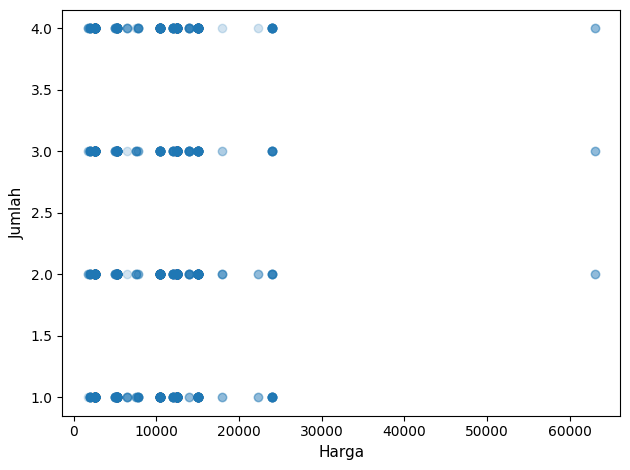

In [11]:
import datetime
# membuat kolom baru bernama "Bulan" yang bertipe datetime dalam format "%m-%Y"
df["Bulan"] = df["Tanggal"].apply(
	lambda x: datetime.datetime.strptime(x, "%d-%m-%Y").strftime("%m-%Y")
)

import matplotlib.pyplot as plt
# plot scatter untuuk kolom "Harga" dan "Jumlah"
plt.scatter(df["Harga"], df["Jumlah"], alpha = 0.2)
plt.xlabel("Harga", fontsize=11)
plt.ylabel("Jumlah", fontsize=11)
plt.tight_layout()
plt.show()

Dari hasil visualisasi ini, aku dapat melihat jumlah produk dibeli berdasarkan harganya. Warna yang lebih gelap menunjukkan lebih banyaknya transaksi dalam jumlah dan harga tersebut. Aku dapat melihat transaksi pada produk dengan harga di atas 60.000 lebih sedikit dibandingkan barang dengan harga 10.000.

## **Grafik Histogram**

Penggunaan histogram untuk menampilkan distribusi jumlah barang yang dibeli per transaksi. Dengan menggunakan fungsi *hist()* yang disediakan oleh library *matplotlib*.





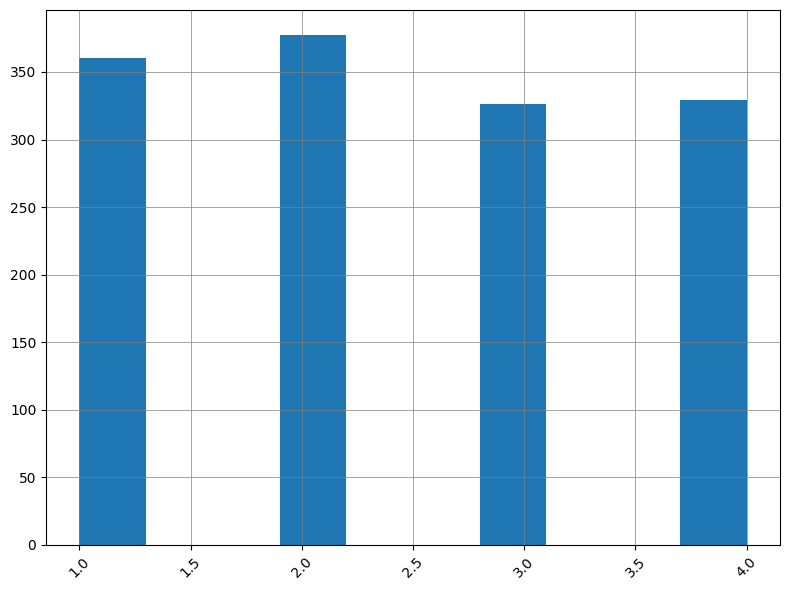

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.hist(df["Jumlah"])
plt.grid(color="gray", linestyle="-", linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **Line Chart**

 Penggunakan Line Chart dalam menganalisa penjualan Mi Goreng Instant sebagai produk yang paling laku, kamu bisa membuat Line Chart dengan data itu,

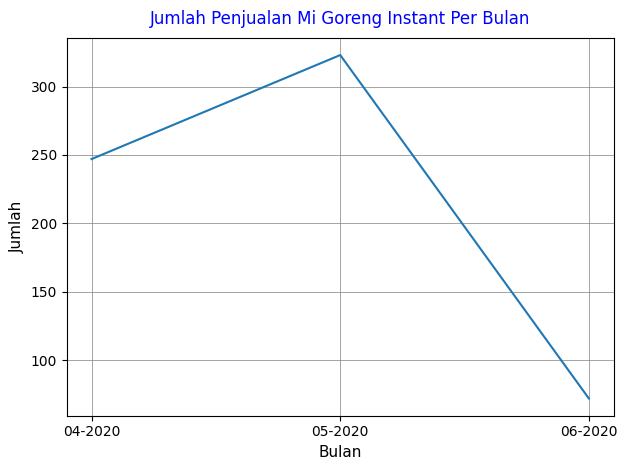

In [13]:

# mengambil data Mi Goreng Instant saja
produk_mi = df[df["Nama Produk"] == "Mi Goreng Instant"]

# x adalah bulan transaksi
x = ["04-2020", "05-2020", "06-2020"]

# y jumlah item Mi Goreng Instant yang terjual
y = produk_mi.groupby(["Bulan","Nama Produk"])["Jumlah"].sum()

# membuat line chart menggunakan fungsi plot
plt.plot(x,y)
plt.title("Jumlah Penjualan Mi Goreng Instant Per Bulan", pad=10, fontsize=12, color="blue")
plt.xlabel("Bulan", fontsize=11)
plt.ylabel("Jumlah", fontsize=11)
plt.grid(color="gray", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()

### **Studi Kasus II.1 Membuat Tabel Frekuensi**

 Pengerjaaan kasus visualisasi data  dimulai dengan tabel frekuensi untuk menampilkan total penjualan per produk dan perbulannya dengan kode sebagai berikut.

```python
# Menghitung total harga untuk setiap row
df["Total"] = df["Harga"] * df["Jumlah"]

# menghitung total penjualan per produk per bulan
print(df.groupby(["Bulan", "Nama Produk"])["Total"].sum())
```



In [15]:
# Menghitung total harga untuk setiap row

# menghitung total penjualan per produk per bulan


**Tugas Praktik 8: Membuat Line Chart**


Manampilkan Grafik Line cart dari penjulan suatu produk




```python
# mengambil data Kopi Instant saja
produk_kopi = df[df["Nama Produk"] == "Kopi Instant"]

# x adalah bulan transaksi
x = ["04-2020", "05-2020", "06-2020"]

# y jumlah item Kopi Instant yang terjual
y = produk_kopi.groupby(["Bulan", "Nama Produk"])["Jumlah"].sum()

import matplotlib.pyplot as plt
# membuat line chart menggunakan fungsi plot
plt.plot(x,y)
plt.title("Jumlah Penjualan Kopi Instant Per Bulan", pad=10, fontsize=12, color="blue")
plt.xlabel("Bulan", fontsize=11)
plt.ylabel("Jumlah",fontsize=11)
plt.grid(color="gray", linestyle="-", linewidth=0.5)
plt.tight_layout()
plt.show()
```



In [16]:
# mengambil data Kopi Instant saja

# x adalah bulan transaksi

# y jumlah item Kopi Instant yang terjual

# membuat line chart menggunakan fungsi plot